# Exploratory Onset Time-Series Walkthrough

This notebook is execution-focused: reusable logic is imported from `monsoonbench.utils.onset_timeseries` rather than defined inline.

Walkthrough plan:
1. Resolve paths and select one analysis case.
2. Run single-point onset diagnostics and inspect the plot.
3. Run cross-type model comparison and export benchmark artifacts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

import monsoonbench.utils.onset_timeseries as ou

## 1) Runtime Paths and Case Settings

Set repository-relative paths, output directory, and one target point/year.

- 1-degree IMD + threshold: point-level diagnostics
- 4-degree IMD + threshold: model-vs-truth cross-type benchmark

In [2]:
cwd = Path.cwd()
repo_root = ou.find_repo_root(cwd)
data_dir = repo_root / "data"
out_dir = repo_root / "examples" / "exploratory_notebooks" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
example_year, example_lat, example_lon = 2019, 24.5, 80.5
imd_1deg_dir = data_dir / "imd_rainfall_data" / "1p0"
thres_1deg_file = data_dir / "imd_onset_threshold" / "mwset1x1.nc4"
imd_4deg_dir = data_dir / "imd_rainfall_data" / "4p0"
thres_4deg_file = data_dir / "imd_onset_threshold" / "mwset4x4.nc4"

## 2) Single-Point Diagnostics

This step loads rainfall at one point, computes onset-rule intermediates, and draws a sanity-check figure.

Key object:
- `diagnostics`: includes intermediate masks, rolling sums, and detected onset date.

In [3]:
rain_file = imd_1deg_dir / f"data_{example_year}.nc"
rain_da = ou.standardize_rainfall_dims(xr.open_dataset(rain_file)["RAINFALL"])
thres_1deg = ou.load_threshold_with_fix(thres_1deg_file)
rain_point = rain_da.sel(lat=example_lat, lon=example_lon, method="nearest")
thres_point_da = thres_1deg.sel(lat=example_lat, lon=example_lon, method="nearest")
threshold_point = float(thres_point_da)
diagnostics = ou.compute_onset_diagnostics(rain_point, threshold_point, example_year)
single_plot = out_dir / "onset_timeseries_example.png"

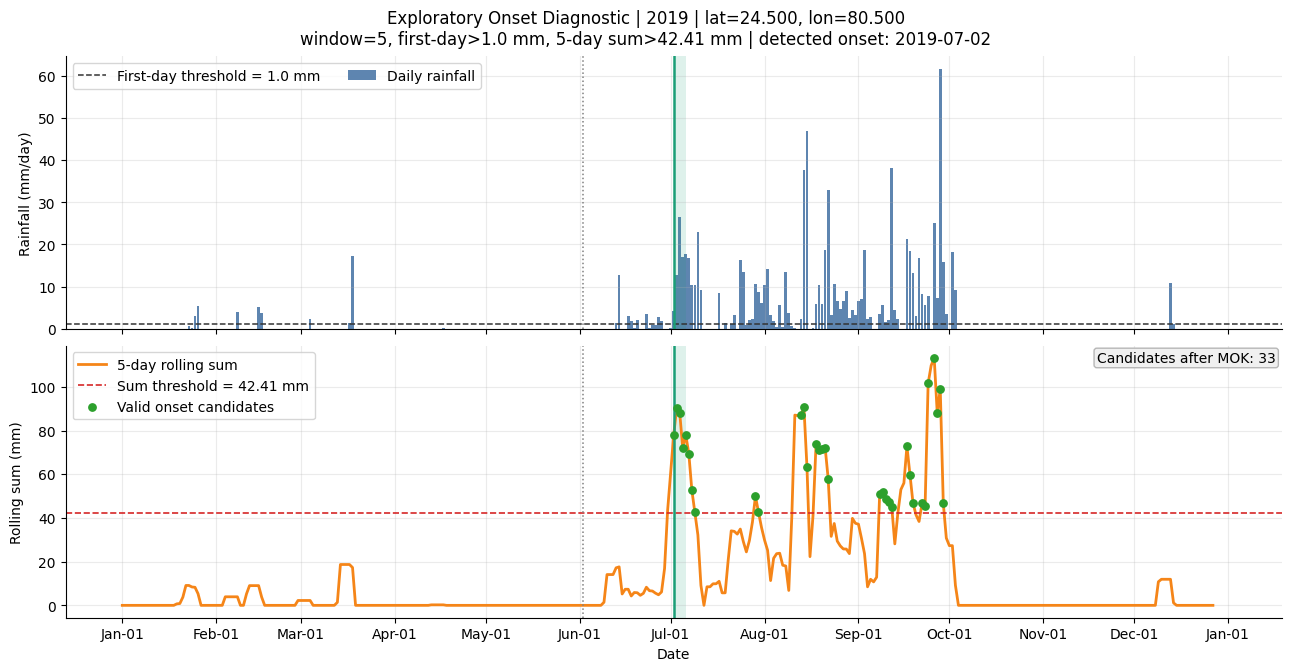

In [4]:
ou.plot_onset_timeseries(
    rain_point, threshold_point, example_year, save_path=single_plot
)
plt.show()

## 3) Cross-Type Comparison

Now compare deterministic and probabilistic models at the same point/year.

Outputs:
- `metrics_df`: aggregated model metrics
- comparison figure and CSV artifacts in `examples/exploratory_notebooks/outputs/`

In [5]:
model_configs = ou.default_cross_type_model_configs(data_dir)
cross_df, member_df = ou.build_cross_type_onset_timeseries(
    example_year, example_lat, example_lon, model_configs, imd_4deg_dir, thres_4deg_file
)
metrics_df = ou.summarize_error_metrics(cross_df)
display(metrics_df)

Loading IMD rainfall from: C:\Users\50573\Documents\AAASlashie\MSCAPP\2026-WINTER\DATA 27100\monsoon-bench\data\imd_rainfall_data\4p0\2019.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection


,model_name,n_inits,n_valid_preds,MAE_days,RMSE_days,Bias_days,MedAE_days,HitRate_+/-2d_pct,HitRate_+/-3d_pct,MissRate_pct,EarlyRate_pct,LateRate_pct,Spread_P90minusP10_days_mean,Spread_P90minusP10_days_median
0,aifs,17,12,6.333333,8.225975,-6.333333,4.5,50.000000,50.000000,29.411765,100.000000,0.000000,NaN,NaN
1,graphcast,17,12,7.416667,9.069179,-7.416667,8.0,33.333333,33.333333,29.411765,100.000000,0.000000,NaN,NaN
2,ifs,17,11,4.272727,5.368257,-3.727273,3.0,36.363636,54.545455,35.294118,72.727273,27.272727,6.907143,6.45
3,ngcm,17,12,4.750000,6.317964,-4.416667,3.0,41.666667,58.333333,29.411765,75.000000,16.666667,9.562500,8.35


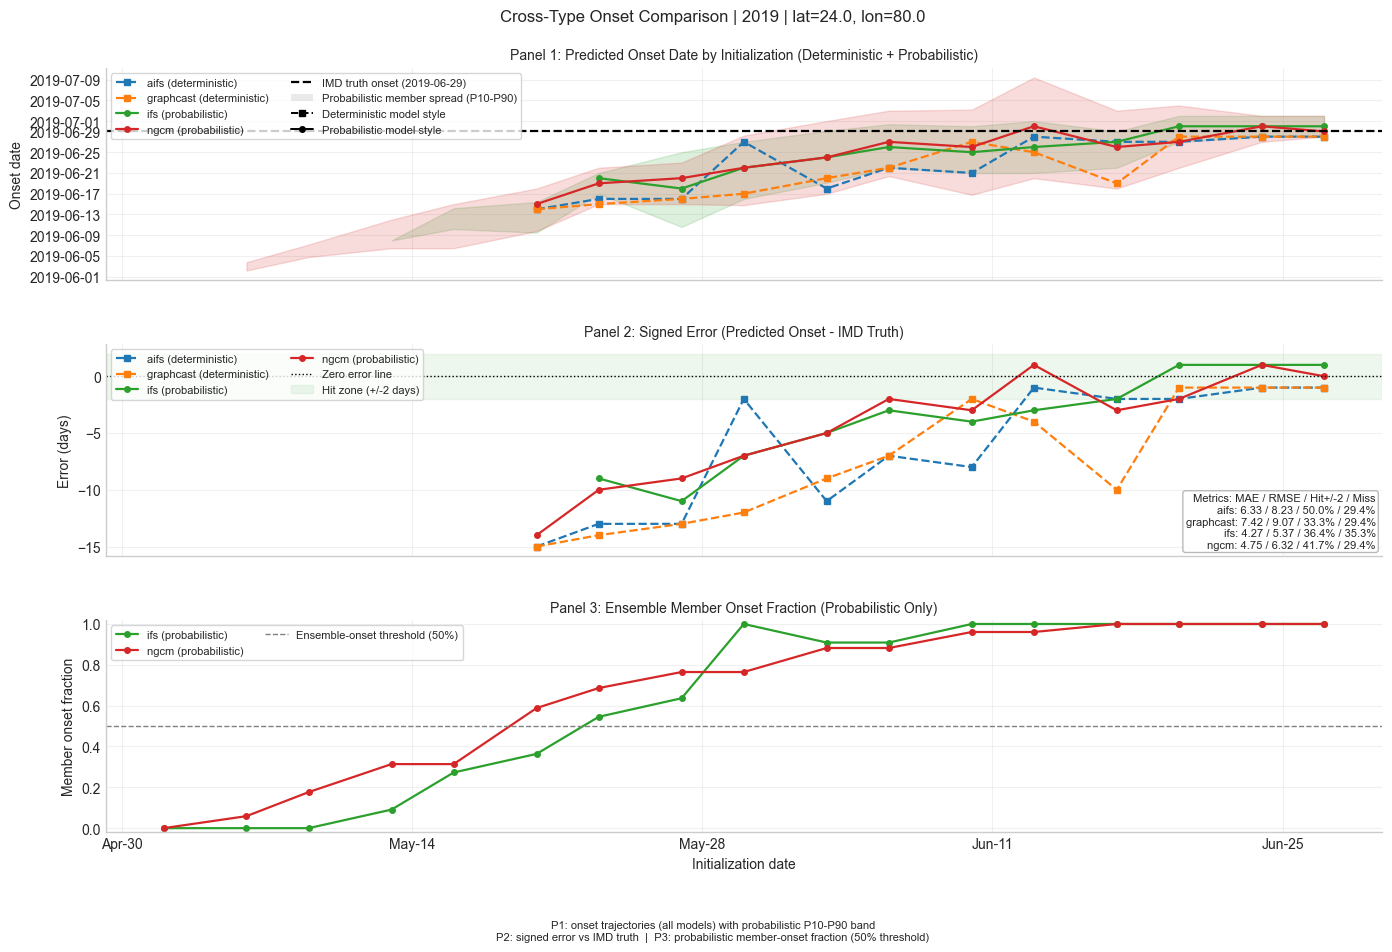

In [6]:
cross_plot = out_dir / "benchmark_cross_type_onset_timeseries.png"
ou.plot_cross_type_onset_comparison(
    cross_df, metrics_df, example_year, save_path=cross_plot
)
metrics_csv = out_dir / "benchmark_cross_type_metrics.csv"
metrics_df.to_csv(metrics_csv, index=False)
if not member_df.empty:
    member_df.to_csv(out_dir / "benchmark_member_level_onset.csv", index=False)